    Instructions:
    1. Run task_0a.py to generate the vector database if not already generated.
    2. Press Run All (or restart kernel and run all cells).
    3. You will be prompted to provide input values.


    – Task 7: Implement a program which, given (a) an (even or odd numbered) imageID 
    or an image file name, (b) a user selected latent semantics, and (c) positive 
    integer k, identifies and visualizes the most similar k images, along with their 
    scores, under the selected latent space.

In [7]:
IMAGE_INPUT = input(
"""
Provide one of the following:
1. An Image ID in the Caltech101 dataset in range [0, 8676].
2. The name of an image file in /Code/input/ directory (eg: image.jpg).
"""
)

LATENT_SEMANTICS = input(
"""
Provide a latent semantic that was generated using tasks 3 to 6.
For eg:
if you generated a latent semantic in task 3 from color space and svd,
enter "LS1_color_svd".
If you are unsure what to type here, please see Code/database/<name>_reducer.pt
after running the relevant task. Any <name> can be input here.
"""
)

K = int(input("Enter K, the K most similar images to find under the latent space."))

Files already downloaded and verified
Input image:  2502


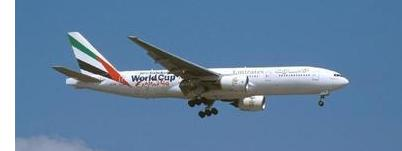

In [8]:
# Find the k most similar images for a given query image for the given latent semantics.

from utils.query_input_processor import get_query_image

image = get_query_image(IMAGE_INPUT)

print("Input image: ", IMAGE_INPUT)
display(image)

In [9]:
# Load corresponding feature space.

LATENT_SPACE = LATENT_SEMANTICS.split('_')[0]

FEATURE_SPACE = LATENT_SEMANTICS.split('_')[1]

from utils.database_utils import retrieve
feature_vectors = retrieve(f'{FEATURE_SPACE}.pt')

# Load corresponding feature reducer.

reducer = retrieve(f'{LATENT_SEMANTICS}_reducer.pt')

In [10]:
if FEATURE_SPACE == 'color':
    from feature_models.color_moments import ColorMomentsExtractor

    vector = ColorMomentsExtractor(image).get_color_vector()

elif FEATURE_SPACE == 'hog':
    from feature_models.hog import HOGExtractor

    vector = HOGExtractor(image).get_hog_vector()

else:
    # ResNet feature model.
    from feature_models.resnet import ResNetExtractor
    resnet = ResNetExtractor(image)

    if FEATURE_SPACE == 'avgpool':
        vector = resnet.get_avgpool_vector()

    elif FEATURE_SPACE == 'layer3':
        vector = resnet.get_layer3_vector()

    elif FEATURE_SPACE == 'fc':
        vector = resnet.get_fc_vector()
    else:
        # resnet_output feature space.
        vector = resnet.get_output_vector()

In [11]:
# Generate feature space latent semantics using reducer.

from utils.vector_utils import get_latent_feature_vectors

latent_feature_vectors = get_latent_feature_vectors(feature_vectors, reducer)

from utils.dataset_utils import initialize_dataset
dataset = initialize_dataset()

Files already downloaded and verified

K = 10  most similar images by  LS1_hog_svd  latent semantics using distance:  correlation
1. 	Image ID:  2502 		Label:  airplanes 		Distance:  0.0


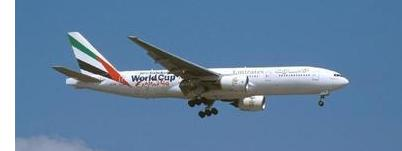

2. 	Image ID:  2608 		Label:  airplanes 		Distance:  0.001586099292608445


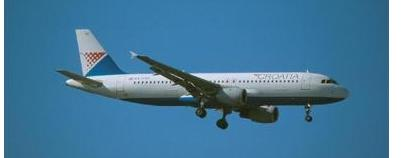

3. 	Image ID:  2630 		Label:  airplanes 		Distance:  0.001805730721143206


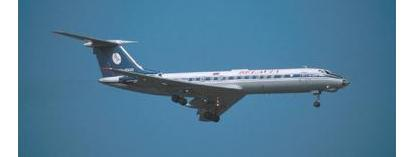

4. 	Image ID:  2620 		Label:  airplanes 		Distance:  0.0021824035631461403


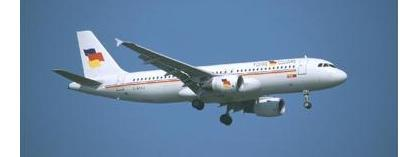

5. 	Image ID:  2496 		Label:  airplanes 		Distance:  0.0025207067739476674


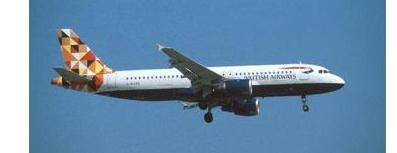

6. 	Image ID:  2498 		Label:  airplanes 		Distance:  0.002577443633180243


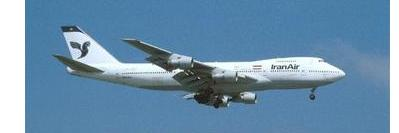

7. 	Image ID:  2194 		Label:  airplanes 		Distance:  0.0028264786154410526


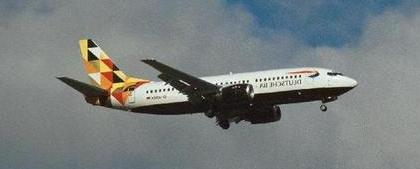

8. 	Image ID:  2610 		Label:  airplanes 		Distance:  0.0028658672965147236


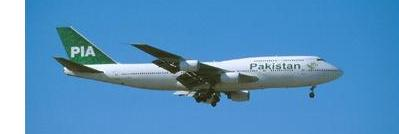

9. 	Image ID:  2618 		Label:  airplanes 		Distance:  0.0029317068942376068


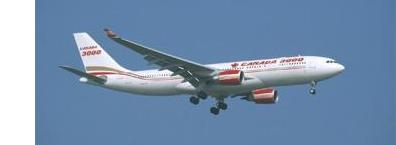

10. 	Image ID:  2594 		Label:  airplanes 		Distance:  0.00301092911832479


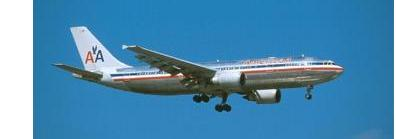

In [12]:
if LATENT_SPACE == 'LS1':

    # Reduce query vector using reducer to latent space.

    # Interface for reducer is Dict(IMG_ID -> (Label, Vector)), it drops everything but the vector.
    latent_vector = reducer.reduce_features({"QUERY": ("UNKNOWN", vector)})[0]

    from utils.distance_utils import get_distance_fn, top_k_distance_ranker
    top_k = top_k_distance_ranker(K, latent_vector, latent_feature_vectors, get_distance_fn(FEATURE_SPACE))

    print("\nK =", K, " most similar images by ", LATENT_SEMANTICS, " latent semantics using distance: ", get_distance_fn(FEATURE_SPACE).__name__)

    for i in range(len(top_k)):

        distance, image_id, label = top_k[i]

        print(str(i + 1) + ".", "\tImage ID: ", image_id, "\t\tLabel: ", label, "\t\tDistance: ", distance)
        display(dataset[image_id][0])

elif LATENT_SPACE == 'LS2':
    pass
elif LATENT_SPACE == 'LS3':
    pass
else:
    # LS4.
    pass